# Logistic Regression Project — Energy Generation Classification -1

**Goal:**  
Build and analyze a logistic regression model to classify whether an energy generation event represents high or low output using the U.S. Energy dataset (`energy.csv`).

---

## This notebook performs:

- **Data loading & inspection**
- **Target creation** (high vs low generation using median threshold)
- **Categorical encoding** (One-Hot Encoding)
- **Feature scaling** (Standardization)
- **Exploratory Data Analysis**  
  (distributions, correlations, bar charts)
- **Model building:**  
  - Custom Logistic Regression (from scratch, gradient descent)  
  - Scikit-learn LogisticRegression comparison  
- **Model evaluation**  
  - Accuracy  
  - Classification report  
  - Confusion matrix  
- **Interpretation of model coefficients**
- **Final conclusion and recommendations**

---

### **Note**

This notebook focuses on a binary classification task derived from continuous energy output.  
If the final objective is pure prediction (e.g., forecasting megawatt-hours), consider switching to regression models and adjusting preprocessing accordingly.


# Imports and Setup

In [2]:
# Step 0 – Imports and settings

import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import OneHotEncoder

# Add src to path so we can import our custom package
import sys
sys.path.append("../../../src")

from rice_ml.processing.scaling import StandardScaler
from rice_ml.supervised_learning.logistic_regression import LogisticRegression
from sklearn.linear_model import LogisticRegression as SkLogisticRegression  # sklearn baseline

DATA_PATH = Path("../../../datasets/energy.csv")
print("Data path:", DATA_PATH.resolve())


Data path: /Users/alansalcedamonge/Desktop/577-project/INDE-577-Final-Project/datasets/energy.csv


# Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (496774, 7)

Columns: ['Unnamed: 0', 'YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE', 'GENERATION (Megawatthours)']


,Unnamed: 0,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,4,2001,1,AK,Total Electric Power Industry,Wind,87.0


# Basic Info and Summary

In [4]:

print(df.info())
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496774 entries, 0 to 496773
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  496774 non-null  int64  
 1   YEAR                        496774 non-null  int64  
 2   MONTH                       496774 non-null  int64  
 3   STATE                       496774 non-null  object 
 4   TYPE OF PRODUCER            496774 non-null  object 
 5   ENERGY SOURCE               496774 non-null  object 
 6   GENERATION (Megawatthours)  496774 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 26.5+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,496774.0,NaN,NaN,NaN,18143.269698,13387.090505,0.0,7762.0,15853.0,24178.0,65144.0
YEAR,496774.0,NaN,NaN,NaN,2011.649768,6.168041,2001.0,2006.0,2012.0,2017.0,2022.0
MONTH,496774.0,NaN,NaN,NaN,6.431452,3.458944,1.0,3.0,6.0,9.0,12.0
STATE,496774,52,US-TOTAL,18322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPE OF PRODUCER,496774,6,Total Electric Power Industry,134452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENERGY SOURCE,496774,14,Total,73356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GENERATION (Megawatthours),496774.0,NaN,NaN,NaN,1393383.817259,10786845.79922,-997855.0,1643.0,23301.03,279204.2175,421796659.0


# Missing Values Overview

In [5]:

missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

# Visualize Missingness

In [6]:


if df.isna().any().any():
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isna(), cbar=False)
    plt.title("Missing value map (True = missing)")
    plt.show()
else:
    print("No missing values detected.")


No missing values detected.


# Create Binary Target

In [7]:
# Step 5 — Create binary target EDA Only

GEN_COL = "GENERATION (Megawatthours)"
assert GEN_COL in df.columns, f"{GEN_COL} not found. Check column names."

threshold_eda = df[GEN_COL].median()
print("EDA median generation threshold:", threshold_eda)

df["target_eda"] = (df[GEN_COL] > threshold_eda).astype(int)
df["target_eda"].value_counts(normalize=True)



EDA median generation threshold: 23301.03


target_eda
1    0.5
0    0.5
Name: proportion, dtype: float64

# Explain Features and Target

### Variables overview

- **YEAR, MONTH** – Time information for each measurement.
- **STATE** – U.S. state code.
- **TYPE OF PRODUCER** – Category of producer (e.g., electric utility, IPP).
- **ENERGY SOURCE** – Primary energy source (coal, natural gas, wind, etc.).
- **GENERATION (Megawatthours)** – Continuous electricity generation quantity.
- **target** – Binary label:
  - `1` = High generation (above median)
  - `0` = Low generation (at or below median)

Goal: model the probability that a given record corresponds to **high** generation.


# EDA Distribution for Numeric Variables

Numeric columns: ['Unnamed: 0', 'YEAR', 'MONTH', 'GENERATION (Megawatthours)', 'target_eda']


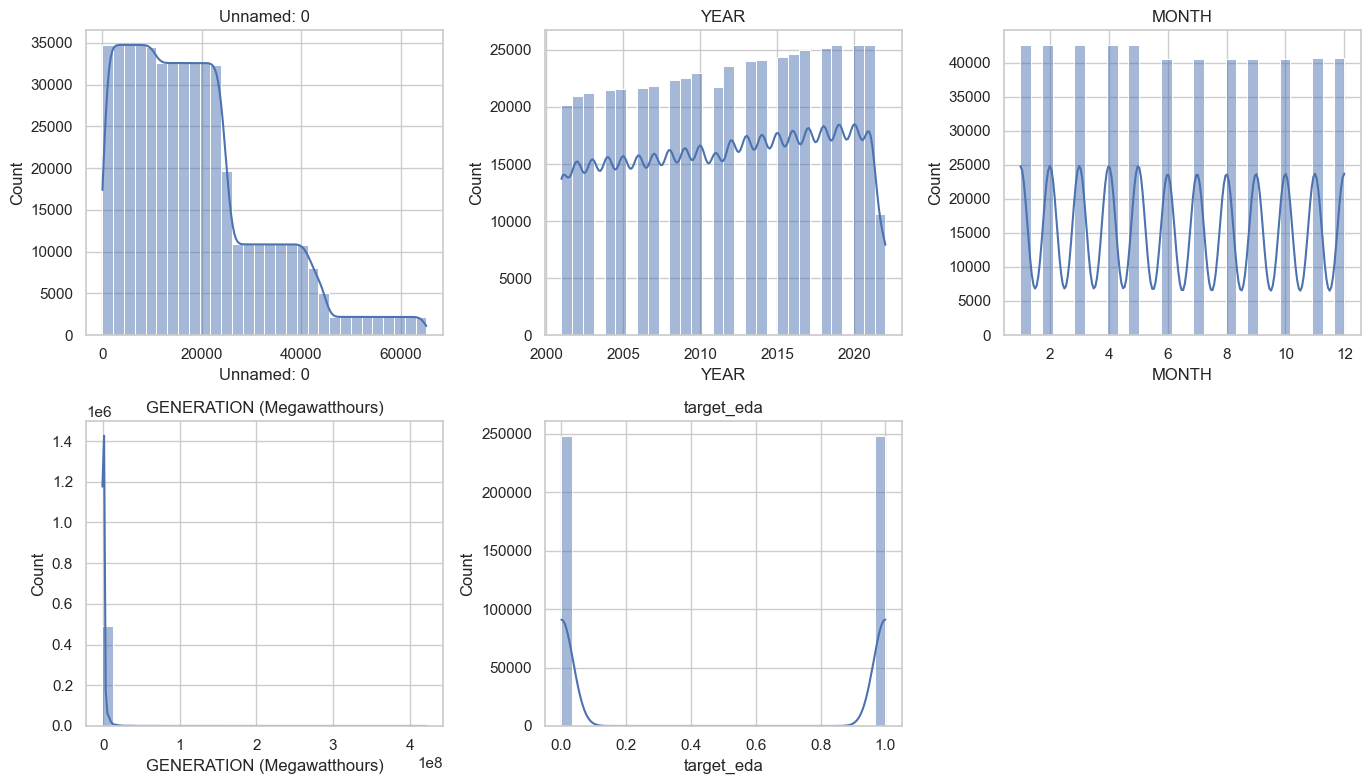

In [8]:
# Step 6 — EDA: distributions for numeric variables

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols):
    plt.subplot(int(np.ceil(len(num_cols) / 3)), 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


# EDA Categorical Distributions

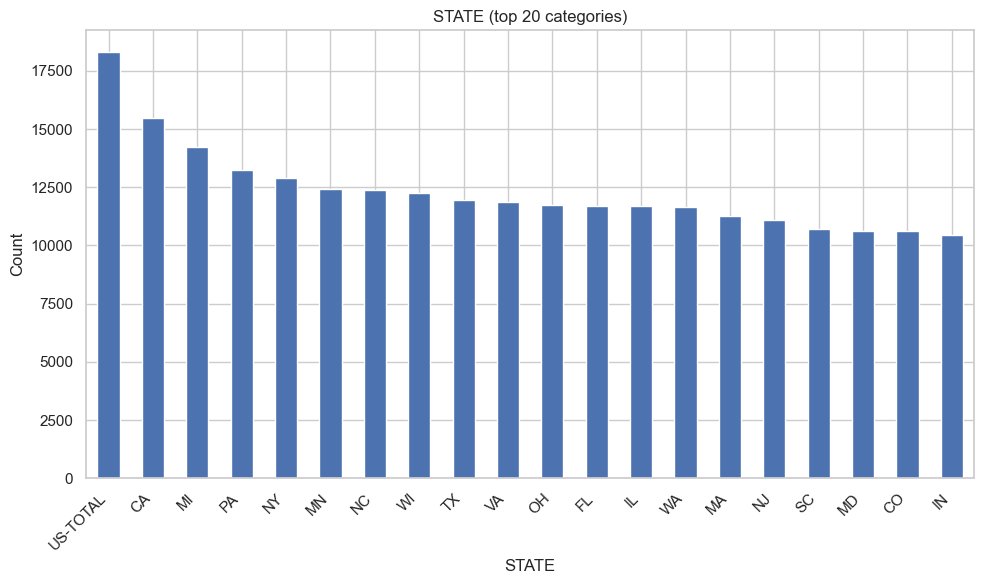

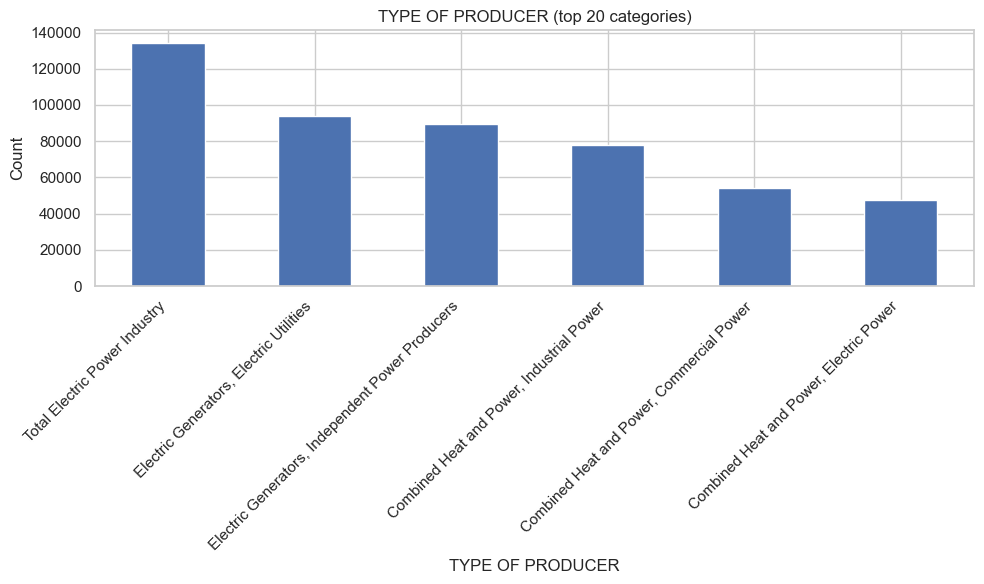

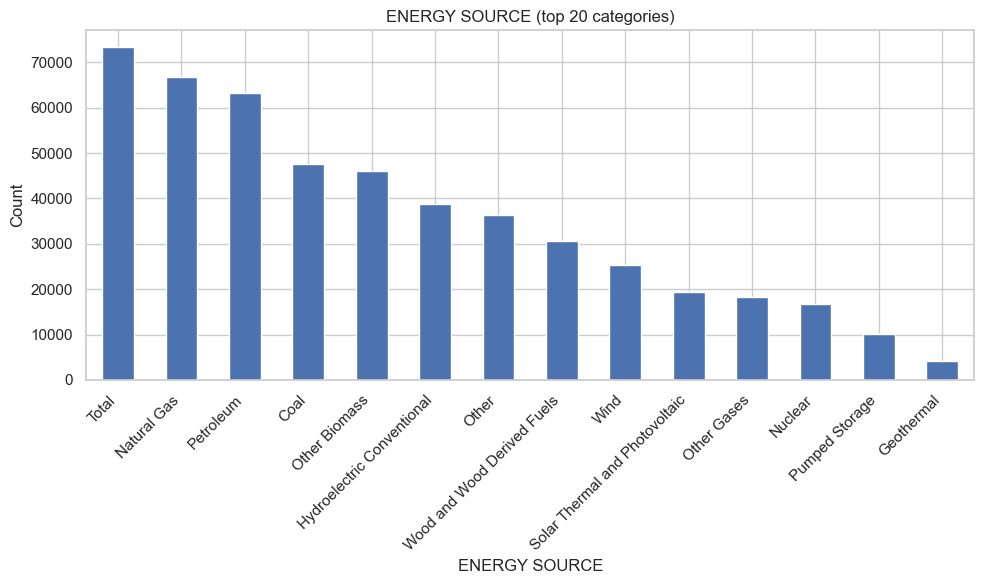

In [9]:
# Step 7 — EDA: categorical feature distributions

cat_cols = ["STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        df[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"{col} (top 20 categories)")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


# Correlation (Only Numeric Values)

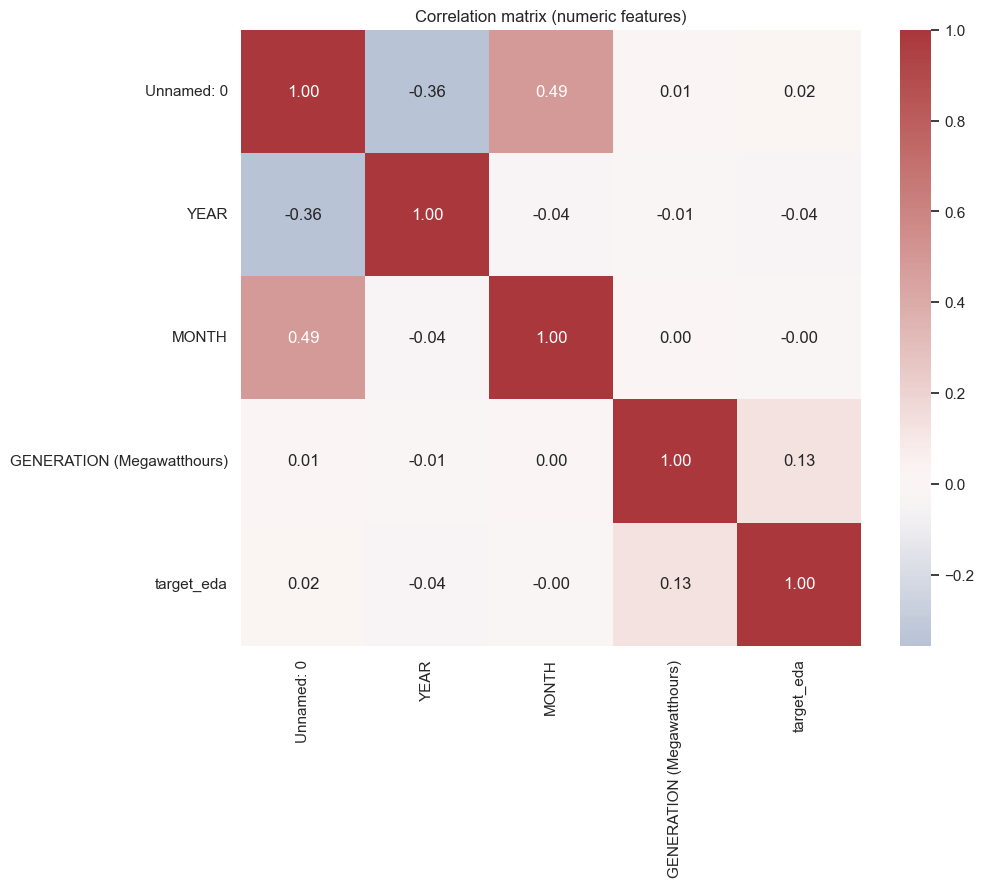

In [10]:
# Step 8 — Correlation matrix for numeric features

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

if "target" in corr.columns:
    print("Correlations with target:")
    print(corr["target"].sort_values(ascending=False))


# Prepare Features

In [11]:
# Step 9 — Prepare raw X and y-source (NO encoding/scaling yet)

# Drop index-like column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

feature_cols = ["YEAR", "MONTH", "STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]
GEN_COL = "GENERATION (Megawatthours)"

X_raw = df[feature_cols].copy()
y_gen = df[GEN_COL].copy()

print("X_raw shape:", X_raw.shape)
print("y_gen shape:", y_gen.shape)



X_raw shape: (496774, 5)
y_gen shape: (496774,)


# Scale Features and Train/Test Splits

In [12]:
# Step 10 — Train/test split FIRST, then target, then encoding+scaling


# 1) Split raw data first
X_train_raw, X_test_raw, y_train_gen, y_test_gen = train_test_split(
    X_raw, y_gen, test_size=0.2, random_state=42
)

# 2) Create target using TRAIN median only
threshold = y_train_gen.median()
y_train = (y_train_gen > threshold).astype(int).values
y_test  = (y_test_gen  > threshold).astype(int).values

print(f"Training median threshold used for modeling: {threshold:.5f}")
print("y_train distribution:", np.bincount(y_train))
print("y_test distribution:", np.bincount(y_test))

# 3) Encode categorical features (fit on train only)
num_features = ["YEAR", "MONTH"]
cat_features = ["STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]

X_train_num = X_train_raw[num_features].reset_index(drop=True)
X_test_num  = X_test_raw[num_features].reset_index(drop=True)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train_raw[cat_features])
X_test_cat  = encoder.transform(X_test_raw[cat_features])

cat_feature_names = encoder.get_feature_names_out(cat_features)
all_feature_names = num_features + list(cat_feature_names)

# Combine numeric + encoded categorical
X_train_all = np.hstack([X_train_num.values, X_train_cat])
X_test_all  = np.hstack([X_test_num.values,  X_test_cat])

# 4) Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled  = scaler.transform(X_test_all)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)



Training median threshold used for modeling: 23292.00000
y_train distribution: [198710 198709]
y_test distribution: [49659 49696]
Train shape: (397419, 74)
Test shape: (99355, 74)


For modeling, we avoid data leakage by (i) computing the median threshold on the training split only, and (ii) fitting the OneHotEncoder and StandardScaler using training data only. GENERATION (Megawatthours) is not used as an input feature; it is used only to construct the target label.

# Fit custom Logistic Regression

In [13]:
# Step 11 — Fit custom Logistic Regression (from rice_ml)

log_reg = LogisticRegression(
    lr=0.05,
    num_iter=8000,
    fit_intercept=True,
    verbose=False
)

log_reg.fit(X_train_scaled, y_train)

# Basic check
print("Model parameters shape:", log_reg.theta.shape)


Model parameters shape: (75,)


# Evaluate Custom logistic Regression

Custom Logistic Regression Accuracy: 0.7950

Classification report (custom model):
              precision    recall  f1-score   support

           0     0.8020    0.7833    0.7925     49659
           1     0.7884    0.8067    0.7974     49696

    accuracy                         0.7950     99355
   macro avg     0.7952    0.7950    0.7950     99355
weighted avg     0.7952    0.7950    0.7950     99355



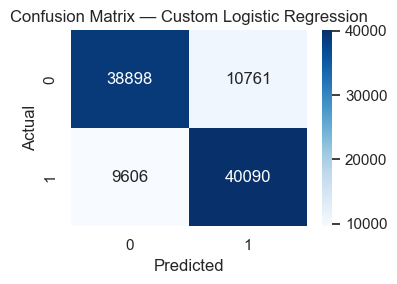

In [14]:
# Step 12 — Evaluation: accuracy, classification report, confusion matrix

y_pred_custom = log_reg.predict(X_test_scaled)
y_proba_custom = log_reg.predict_proba(X_test_scaled)


acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Custom Logistic Regression Accuracy: {acc_custom:.4f}\n")

print("Classification report (custom model):")
print(classification_report(y_test, y_pred_custom, digits=4))

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Custom Logistic Regression")
plt.tight_layout()
plt.show()


# ROC Curve and AUC

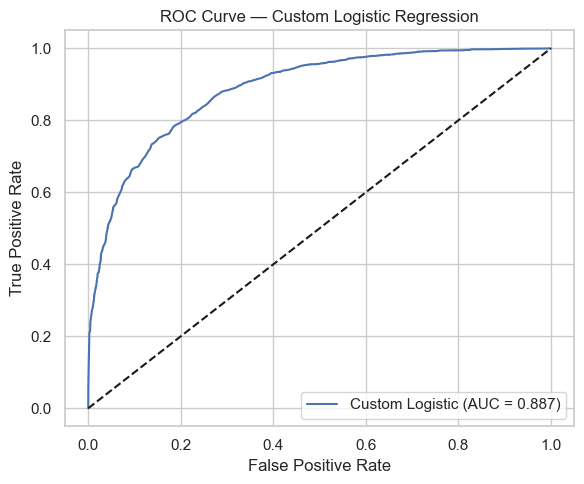

Custom Logistic Regression AUC: 0.8870349575152121


In [15]:
# Step 13 — ROC curve and AUC for custom model

fpr, tpr, thresholds = roc_curve(y_test, y_proba_custom)
roc_auc_custom = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Custom Logistic (AUC = {roc_auc_custom:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Custom Logistic Regression AUC:", roc_auc_custom)


# Compare with scikit-learn LogisticRegression

In [17]:
# Step 14 — Comparison with scikit-learn LogisticRegression

sk_model = SkLogisticRegression(max_iter=1000)
sk_model.fit(X_train_scaled, y_train)

y_pred_sk  = sk_model.predict(X_test_scaled)
y_proba_sk = sk_model.predict_proba(X_test_scaled)[:, 1]

acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"Sklearn LogisticRegression Accuracy: {acc_sk:.4f}\n")

print("Classification report (sklearn):")
print(classification_report(y_test, y_pred_sk, digits=4))

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)
roc_auc_sk = auc(fpr_sk, tpr_sk)
print("Sklearn LogisticRegression AUC:", roc_auc_sk)


Sklearn LogisticRegression Accuracy: 0.7950

Classification report (sklearn):
              precision    recall  f1-score   support

           0     0.8020    0.7833    0.7925     49659
           1     0.7884    0.8067    0.7975     49696

    accuracy                         0.7950     99355
   macro avg     0.7952    0.7950    0.7950     99355
weighted avg     0.7952    0.7950    0.7950     99355

Sklearn LogisticRegression AUC: 0.8870338545324704


# Plot ROC Curves Together

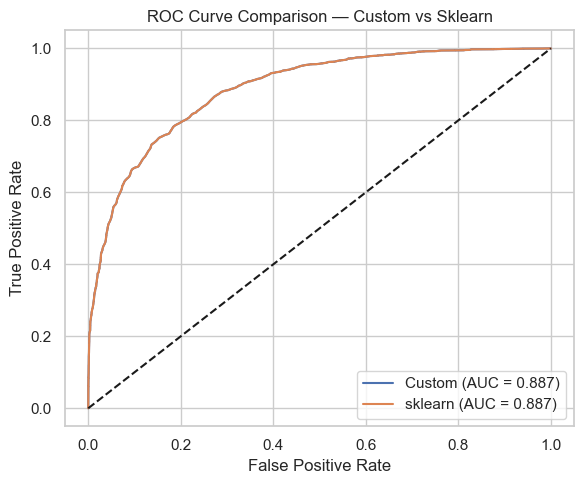

In [18]:
# Step 15 — ROC comparison: custom vs sklearn

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Custom (AUC = {roc_auc_custom:.3f})")
plt.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC = {roc_auc_sk:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Custom vs Sklearn")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Cross validation

In [20]:
# Step 16 — 5-fold cross-validation (leakage-safe)

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = []

num_features = ["YEAR", "MONTH"]
cat_features = ["STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]

# Use RAW training data ONLY for CV
X_cv_raw = X_train_raw.reset_index(drop=True)
y_cv = y_train

for train_idx, val_idx in kf.split(X_cv_raw, y_cv):

    # Split fold
    X_tr_raw = X_cv_raw.iloc[train_idx]
    X_val_raw = X_cv_raw.iloc[val_idx]
    y_tr = y_cv[train_idx]
    y_val = y_cv[val_idx]

    # ---- Encode categorical (fit on fold-train only)
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_tr_cat = encoder.fit_transform(X_tr_raw[cat_features])
    X_val_cat = encoder.transform(X_val_raw[cat_features])

    # ---- Numeric
    X_tr_num = X_tr_raw[num_features].values
    X_val_num = X_val_raw[num_features].values

    # ---- Combine
    X_tr_all = np.hstack([X_tr_num, X_tr_cat])
    X_val_all = np.hstack([X_val_num, X_val_cat])

    # ---- Scale (fit on fold-train only)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_all)
    X_val_scaled = scaler.transform(X_val_all)

    # ---- Train custom Logistic Regression
    model_cv = LogisticRegression(
        lr=0.05,
        num_iter=8000,
        fit_intercept=True,
        verbose=False
    )

    model_cv.fit(X_tr_scaled, y_tr)
    preds_val = model_cv.predict(X_val_scaled)

    cv_acc.append(accuracy_score(y_val, preds_val))

print("CV Accuracy scores:", np.round(cv_acc, 4))
print("Mean CV Accuracy:", np.round(np.mean(cv_acc), 4))



CV Accuracy scores: [0.7938 0.7923 0.7923 0.7956 0.7959]
Mean CV Accuracy: 0.794


# Interpretation

The logistic regression model demonstrates strong discriminatory ability (AUC ≈ 0.887) when predicting whether a given generation record represents high versus low output. Class performance remains well-balanced due to the use of a median-based threshold derived from the training set. The most influential predictors are associated with energy source type and producing state, which aligns with established generation patterns in the U.S. energy sector. While the model relies on relatively coarse contextual features, it provides meaningful interpretability and useful baseline predictive performance. Further improvements could be achieved by incorporating richer temporal dynamics and more granular generation-related variables. Overall, the results indicate solid predictive capability and practical interpretability for decision-making in energy planning contexts.

Important to note: All preprocessing and target construction steps were performed using training data only to avoid information leakage.
